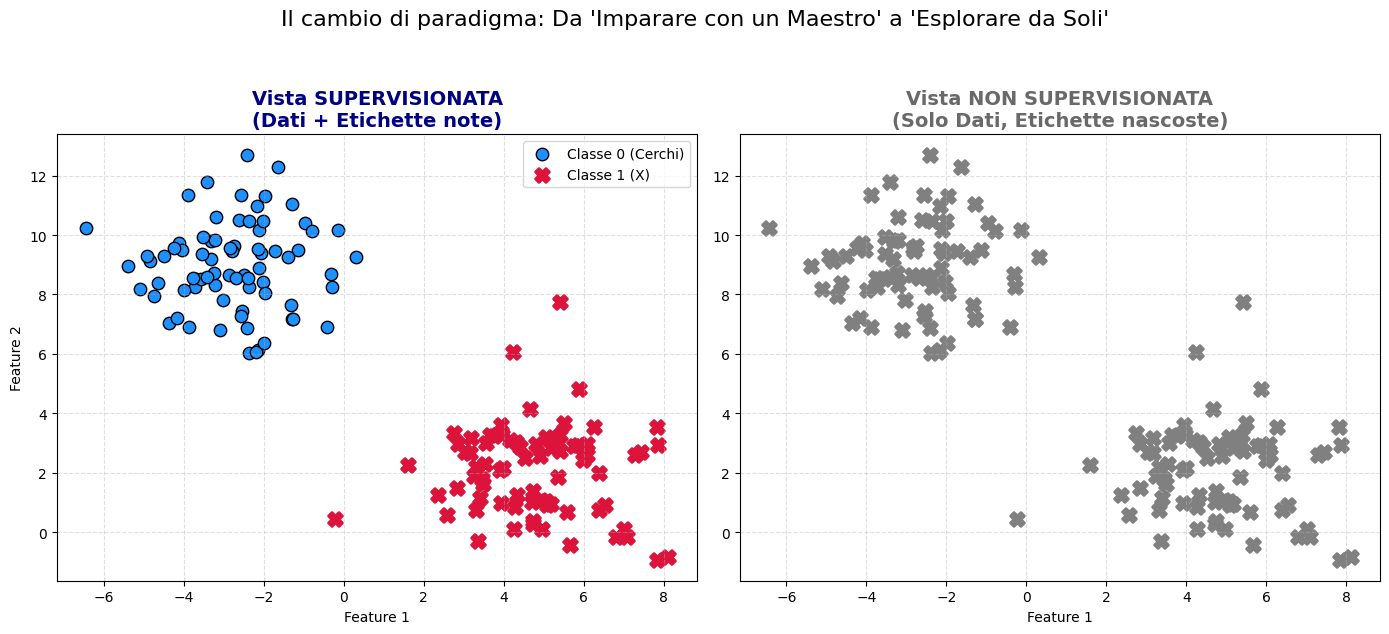

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

# --- 1. Generazione dei Dati ---
# Creiamo un dataset sintetico con 2 centri (classificazione binaria)
# X_data contiene le coordinate, y_labels contiene le etichette (0 o 1)
X_data, y_labels = make_blobs(n_samples=150, centers=2, n_features=2, random_state=42, cluster_std=1.5)

# --- 2. Setup del Doppio Grafico (Subplots) ---
# Creiamo una figura con 1 riga e 2 colonne
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 3. Grafico di Sinistra: Vista Supervisionata (Classificazione) ---
# Disegniamo i punti della Classe 0 (Cerchi blu)
ax1.scatter(X_data[y_labels == 0, 0], X_data[y_labels == 0, 1],
            marker='o', color='dodgerblue', s=80, edgecolor='k', label='Classe 0 (Cerchi)')

# Disegniamo i punti della Classe 1 (X rosse)
ax1.scatter(X_data[y_labels == 1, 0], X_data[y_labels == 1, 1],
            marker='X', color='crimson', s=100, linewidth=2, label='Classe 1 (X)')

ax1.set_title("Vista SUPERVISIONATA\n(Dati + Etichette note)", fontsize=14, fontweight='bold', color='navy')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# --- 4. Grafico di Destra: Vista Non Supervisionata (Clustering) ---
# Disegniamo TUTTI i punti dello stesso dataset, ma senza distinzione di classe
# Usiamo un colore neutro (grigio) e lo stesso marker (X) per tutti
ax2.scatter(X_data[:, 0], X_data[:, 1],
            marker='X', color='gray', s=100, linewidth=2, label='Dati non etichettati')

ax2.set_title("Vista NON SUPERVISIONATA\n(Solo Dati, Etichette nascoste)", fontsize=14, fontweight='bold', color='dimgray')
ax2.set_xlabel("Feature 1")
# ax2.set_ylabel("Feature 2") # Non serve ripetere la label Y
ax2.grid(True, linestyle='--', alpha=0.4)
# ax2.legend() # Non serve la legenda qui, sono tutti uguali

# --- 5. Titolo Generale e Layout ---
plt.suptitle("Il cambio di paradigma: Da 'Imparare con un Maestro' a 'Esplorare da Soli'", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('unsupervised_learning.png')
plt.show()

# Clustering K means

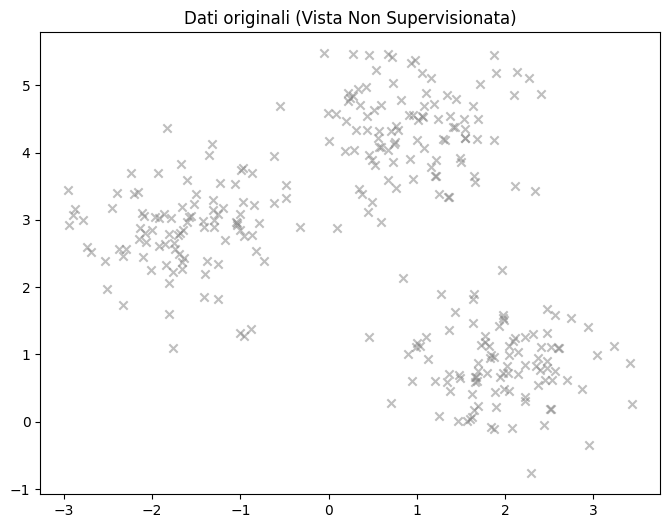

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generiamo 3 gruppi di dati chiari
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Visualizzazione iniziale: i dati appaiono come "X" grigie (senza etichette)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='gray', marker='x', alpha=0.5)
plt.title("Dati originali (Vista Non Supervisionata)")
plt.show()

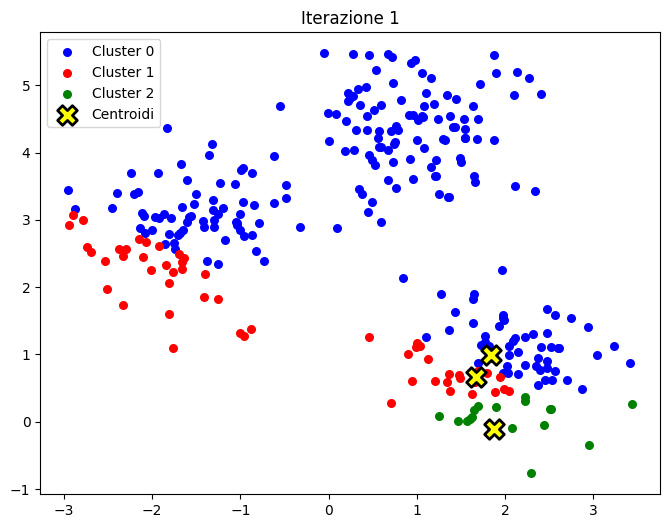

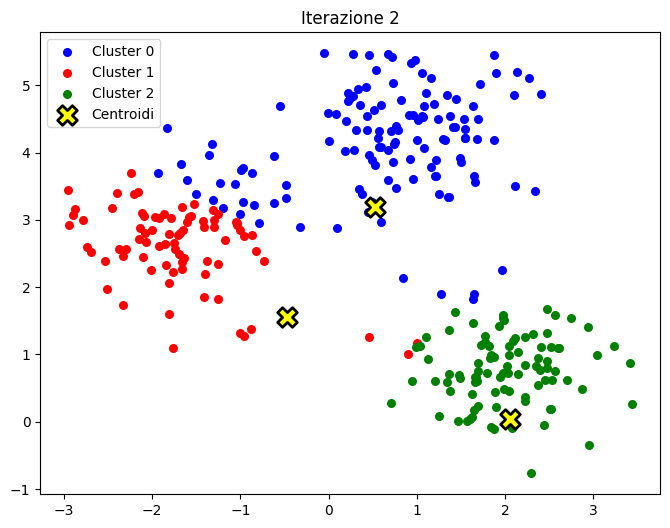

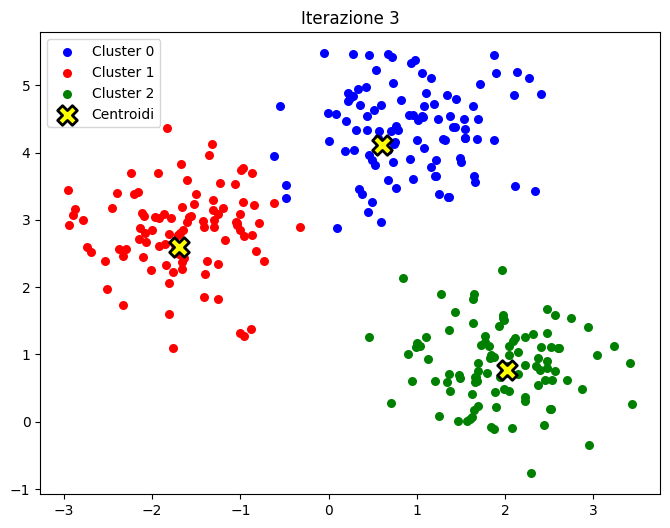

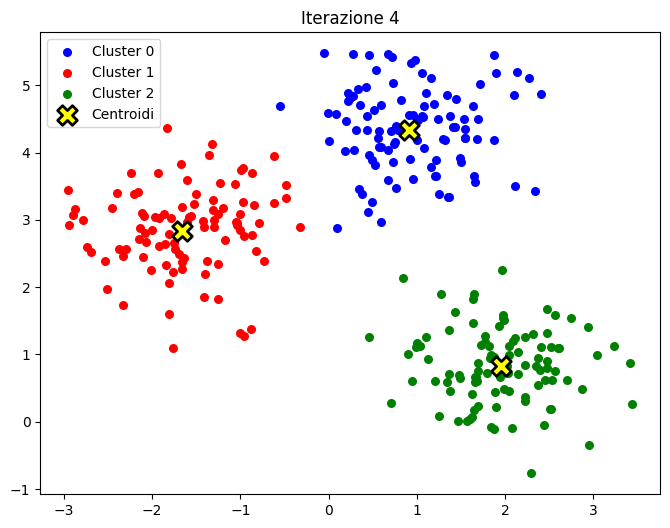

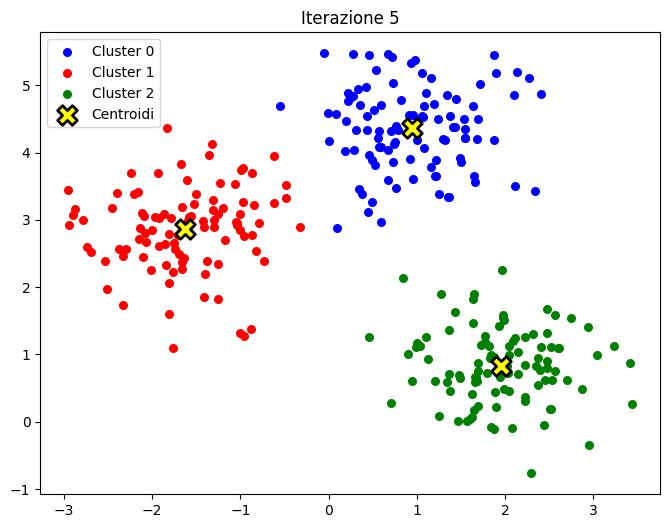

Convergenza raggiunta all'iterazione 5!


In [7]:
def plot_kmeans_step(X, centroids, labels, iteration):
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green']
    
    # 1. Disegniamo i punti colorati in base al cluster assegnato
    for i in range(len(centroids)):
        points = X[labels == i]
        plt.scatter(points[:, 0], points[:, 1], s=30, c=colors[i], label=f'Cluster {i}')
        
    # 2. Disegniamo i centroidi (le nostre "X" giganti)
    plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='yellow', marker='X', 
                edgecolor='black', linewidth=2, label='Centroidi')
    
    plt.title(f"Iterazione {iteration}")
    plt.legend()
    plt.show()

# --- LOGICA K-MEANS ---

# 1. Inizializzazione: scegliamo 3 punti a caso dal dataset come centroidi iniziali
K = 3
random_indices = np.random.choice(len(X), K, replace=False)
centroids = X[random_indices]

# Iniziamo con etichette a zero
labels = np.zeros(len(X))

max_iterations = 5

for i in range(max_iterations):
    # FASE A: ASSEGNAZIONE
    # Calcoliamo la distanza euclidea di ogni punto da ogni centroide
    # Usiamo il broadcasting di numpy per efficienza
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    
    # Assegniamo ogni punto al centroide più vicino
    labels = np.argmin(distances, axis=1)
    
    # Visualizziamo lo stato attuale
    plot_kmeans_step(X, centroids, labels, i + 1)
    
    # FASE B: AGGIORNAMENTO
    # Spostiamo ogni centroide nella media dei punti che gli sono stati assegnati
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
    
    # Se i centroidi non si muovono più, siamo arrivati a convergenza
    if np.all(centroids == new_centroids):
        print(f"Convergenza raggiunta all'iterazione {i+1}!")
        break
        
    centroids = new_centroids

# Anomaly detection. Desnity estimation

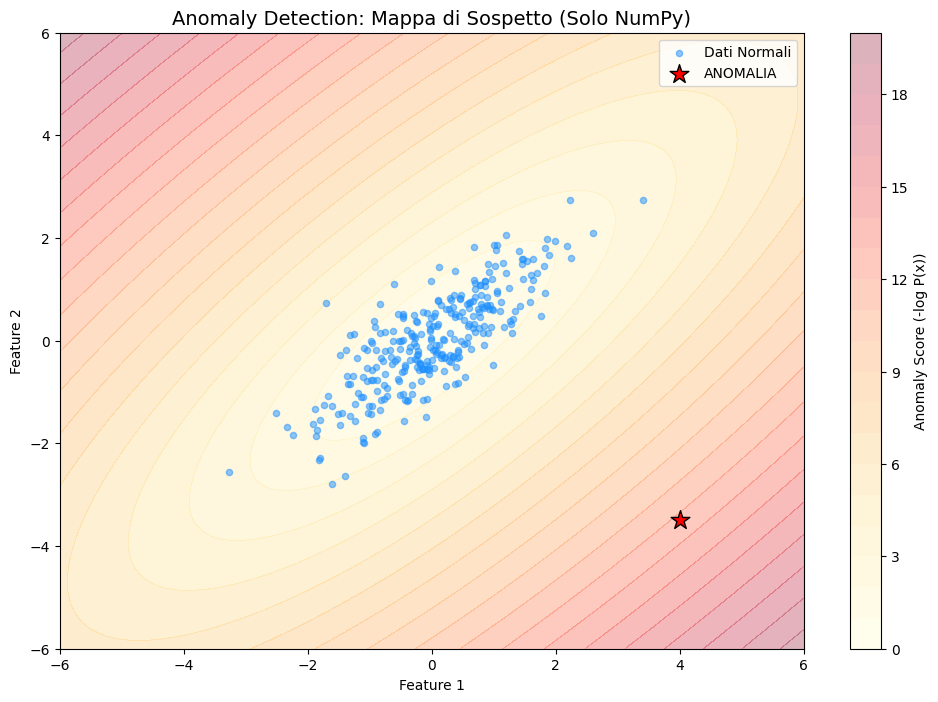

Score dell'anomalia: 12.25


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERAZIONE DEL DATASET (Simulazione dati reali)
np.random.seed(42)
# Dati "Normali": 300 campioni con una certa correlazione
mean_real = [0, 0]
cov_real = [[1, 0.8], [0.8, 1]] 
X_train = np.random.multivariate_normal(mean_real, cov_real, 300)

# Aggiungiamo un'anomalia manuale (un dato inusuale) 
X_anomaly = np.array([[4, -3.5]])

# 2. STIMA DEI PARAMETRI (Apprendimento Non Supervisionato)
# Calcoliamo media (mu) e matrice di covarianza (sigma) dai dati 
mu = np.mean(X_train, axis=0)
sigma = np.cov(X_train, rowvar=False)

def compute_anomaly_score(X, mu, sigma):
    """
    Calcola l'Anomaly Score basato sulla Distribuzione Gaussiana Multivariata.
    Score = -log(P(x))
    """
    k = mu.shape[0] # Numero di feature (dimensione dello spazio)
    sigma_inv = np.linalg.inv(sigma)
    sigma_det = np.linalg.det(sigma)
    
    # Distanza di Mahalanobis quadratica: (x - mu).T * Sigma^-1 * (x - mu)
    diff = X - mu
    # Calcolo vettorizzato per gestire più punti contemporaneamente
    mahalanobis_sq = np.sum(np.dot(diff, sigma_inv) * diff, axis=1)
    
    # Formula del logaritmo negativo della densità (Anomaly Score)
    # Più il valore è alto, più il punto è "inusuale" [cite: 484]
    return mahalanobis_sq ** 0.5

# 3. CALCOLO DEGLI SCORE
scores_train = compute_anomaly_score(X_train, mu, sigma)
score_outlier = compute_anomaly_score(X_anomaly, mu, sigma)

# Definiamo una soglia epsilon (es. il valore che separa il 2% dei dati più rari)

# 4. VISUALIZZAZIONE
plt.figure(figsize=(12, 8))

# Creazione di una griglia per lo sfondo colorato (Heatmap di densità)
x_min, x_max = -6, 6
y_min, y_max = -6, 6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = compute_anomaly_score(grid_points, mu, sigma).reshape(xx.shape)

# Plot dello score (aree rosse = alta anomalia)
contour = plt.contourf(xx, yy, grid_scores, levels=20, cmap='YlOrRd', alpha=0.3)
plt.colorbar(contour, label='Anomaly Score (-log P(x))')

# Plot dei punti
plt.scatter(X_train[:, 0], X_train[:, 1], c='dodgerblue', s=20, alpha=0.5, label='Dati Normali')
plt.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c='red', marker='*', s=200, edgecolors='black', label='ANOMALIA')

plt.title("Anomaly Detection: Mappa di Sospetto (Solo NumPy)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print(f"Score dell'anomalia: {score_outlier[0]:.2f}")

In [13]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Carichiamo i dati
data = load_wine()
X = data.data
y = data.target
target_names = data.target_names
df = pd.DataFrame(X, columns = data.feature_names)
# 1. Standardizzazione (Fondamentale!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [14]:
# 2. Creiamo l'oggetto PCA per 2 componenti
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Trasformiamo in DataFrame per comodità
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Target'] = y

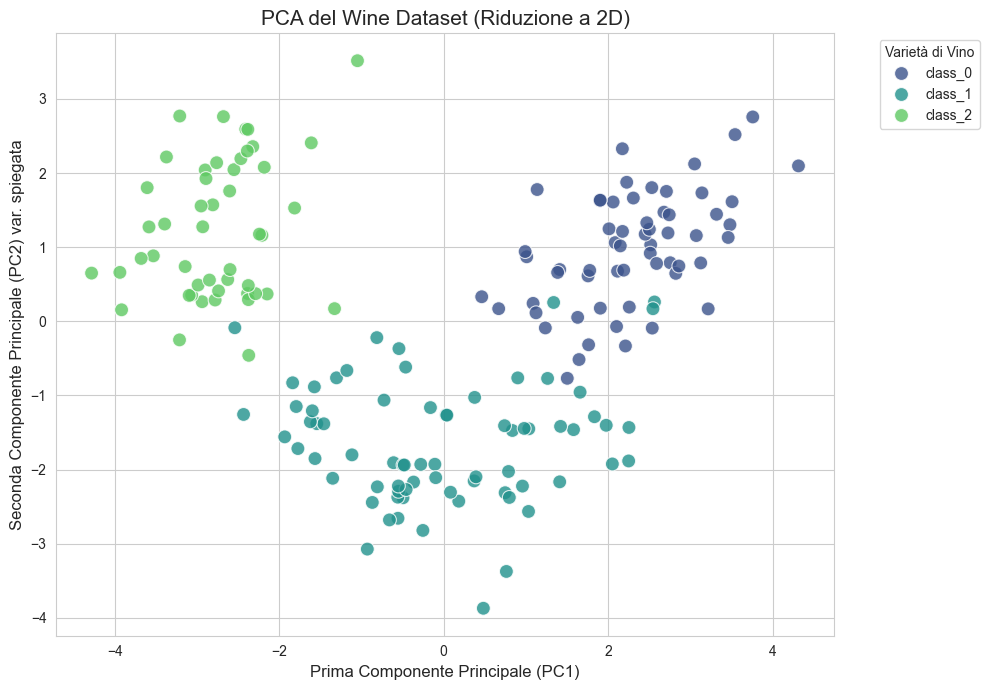

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
df_pca['Tipo di Vino'] = [target_names[i] for i in y]

# 5. Visualizzazione sull'asse cartesiano
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Creazione dello scatter plot
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Tipo di Vino', 
    palette='viridis', 
    data=df_pca, 
    s=100, 
    alpha=0.8,
    edgecolor='w'
)

# Aggiunta di titoli e label
plt.title('PCA del Wine Dataset (Riduzione a 2D)', fontsize=15)
plt.xlabel(f'Prima Componente Principale (PC1)', fontsize=12)
plt.ylabel(f'Seconda Componente Principale (PC2) var. spiegata', fontsize=12)
plt.legend(title='Varietà di Vino', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Implementazione PCA con AutoEncoder

La nostra Loss totale sarà:$$Loss = \underbrace{\text{MSE}(x, \hat{x})}_{\text{Errore di ricostruzione}} + \beta \cdot \underbrace{\| W W^T - I \|^2}_{\text{Penalità di Ortogonalità}}$$Dove $\beta$ è un parametro che decide quanto "severo" deve essere il vincolo.